Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Expression range: 0.0 to 172.545 median: 2.266297262
High-expression threshold (90th percentile): 9.92
High-interaction threshold (95th percentile): 4.54
Number of operon pairs with high interaction & co-expression: 149
Top 5 pairs:
Rv3049c_up - Rv3051c_up: Hi-C=11.851, ExprA=10.64, ExprB=25.56
Rv1642_up - Rv1643_up: Hi-C=11.386, ExprA=44.86, ExprB=35.10
Rv3875_up - Rv3872_up: Hi-C=11.296, ExprA=90.29, ExprB=10.21
Rv2940c_up - Rv2941_up: Hi-C=11.222, ExprA=21.60, ExprB=12.09
Rv1297_up - Rv1298_u

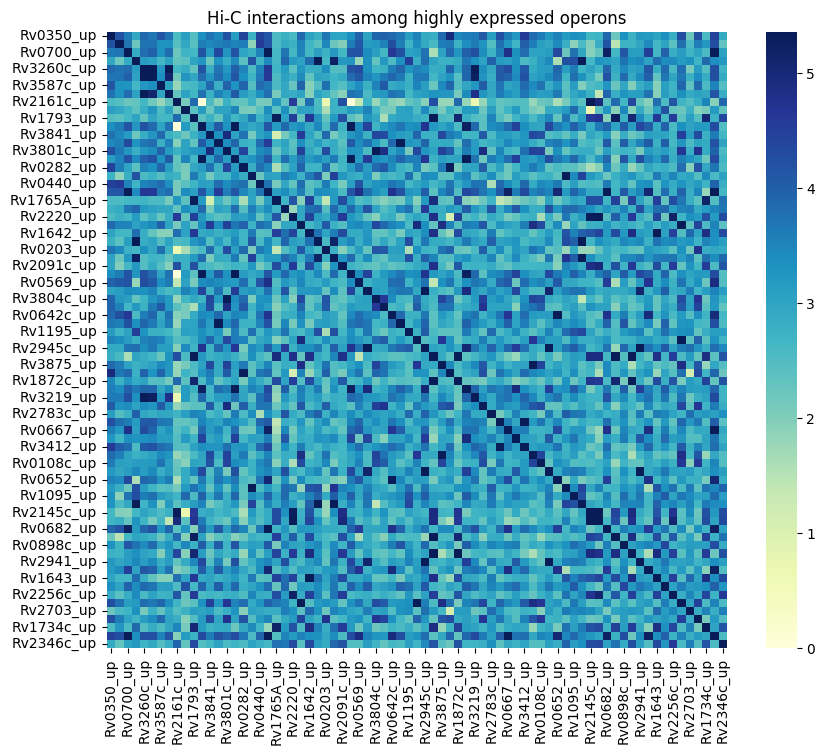

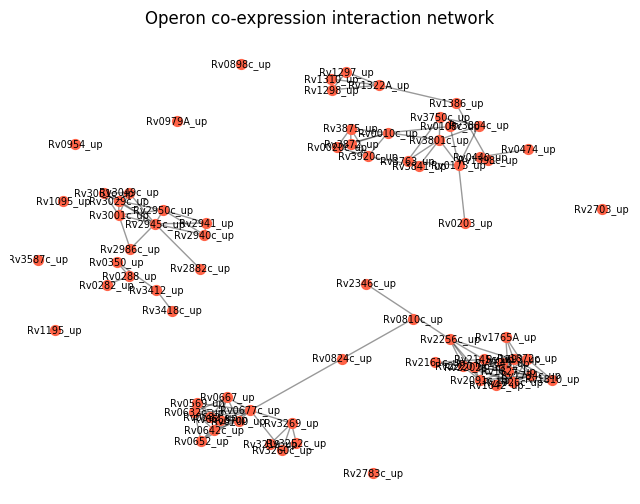

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# 1. 读取数据
operon_expr_df = pd.read_csv('operon_list_updated.csv')
interaction_matrix = pd.read_csv('operon_interaction_matrix.csv', index_col=0)

# 2. 提取表达相关信息
expr_values = operon_expr_df['normalized_expression'].values

# 可选：查看表达分布统计
print("Expression range:", np.min(expr_values), "to", np.max(expr_values),
      "median:", np.median(expr_values))

# 3. 计算高表达和高互作阈值
high_expr_thresh = np.percentile(expr_values, 90)   # 90th percentile for expression
hic_matrix_vals = interaction_matrix.to_numpy()
high_hic_thresh = np.percentile(hic_matrix_vals[np.triu_indices_from(hic_matrix_vals, k=1)], 95)  # 95th percentile for Hi-C
print(f"High-expression threshold (90th percentile): {high_expr_thresh:.2f}")
print(f"High-interaction threshold (95th percentile): {high_hic_thresh:.2f}")

# 4. 获取高表达操纵子列表
high_expr_operons = operon_expr_df[operon_expr_df['normalized_expression'] >= high_expr_thresh]['operon_name'].values

# 5. 筛选高互作且高表达的操纵子对
significant_pairs = []
for i in range(len(high_expr_operons)):
    for j in range(i+1, len(high_expr_operons)):
        op1 = high_expr_operons[i]; op2 = high_expr_operons[j]
        hic_val = interaction_matrix.loc[op1, op2]
        if hic_val >= high_hic_thresh:
            expr1 = float(operon_expr_df.loc[operon_expr_df['operon_name']==op1, 'normalized_expression'])
            expr2 = float(operon_expr_df.loc[operon_expr_df['operon_name']==op2, 'normalized_expression'])
            significant_pairs.append((op1, op2, hic_val, expr1, expr2))
# 按互作强度排序
significant_pairs.sort(key=lambda x: -x[2])
print(f"Number of operon pairs with high interaction & co-expression: {len(significant_pairs)}")
print("Top 5 pairs:")
for op1, op2, hic, expr1, expr2 in significant_pairs[:5]:
    print(f"{op1} - {op2}: Hi-C={hic:.3f}, ExprA={expr1:.2f}, ExprB={expr2:.2f}")

# 6. 可视化：绘制热图（高表达操纵子的Hi-C子矩阵）
sub_matrix = interaction_matrix.loc[high_expr_operons, high_expr_operons]
plt.figure(figsize=(10,8))
sns.heatmap(sub_matrix, cmap="YlGnBu", vmax=np.percentile(hic_matrix_vals, 99))
plt.title("Hi-C interactions among highly expressed operons")
plt.show()

# 7. 可视化：构建网络图
G = nx.Graph()
G.add_nodes_from(high_expr_operons)
for op1, op2, hic, expr1, expr2 in significant_pairs:
    G.add_edge(op1, op2, weight=hic)
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='tomato')
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=7)
plt.title("Operon co-expression interaction network")
plt.axis('off')
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Mean interaction μ=3.184, σ=0.825
General high-intensity threshold = 4.834
Strict high-intensity threshold = 5.658
Number of high-confidence interactions: 1151
Top 5 operon interactions (after filtering):
Rv1199c_up -- Rv1363c_up, strength = 7.842
Rv1200_up -- Rv1363c_up, strength = 7.842
Rv1193_up -- Rv1363c_up, strength = 7.096
Rv1194c_up -- Rv1363c_up, strength = 7.096
Rv1195_up -- Rv1363c_up, strength = 7.096


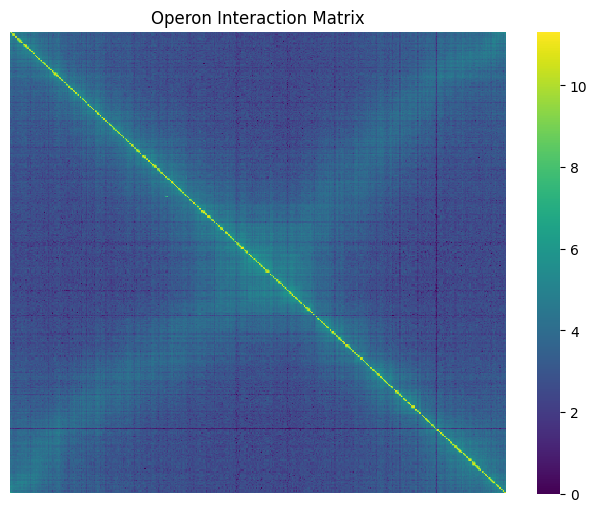

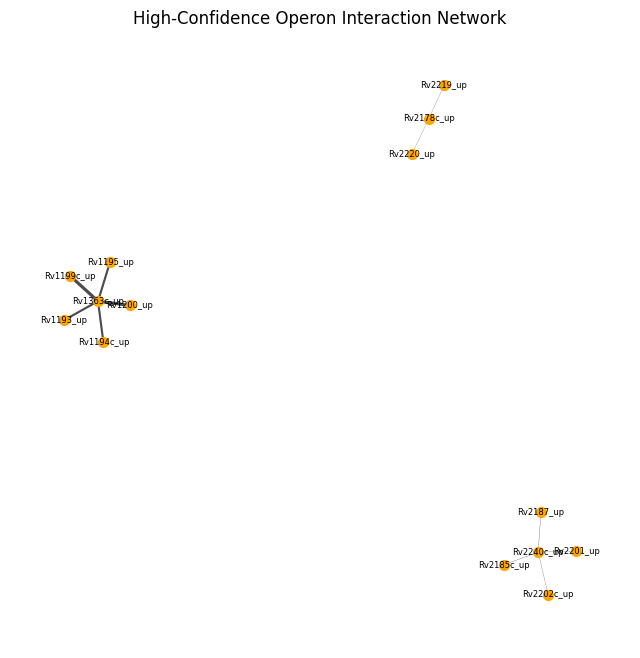

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# 1. 读取数据
df_matrix = pd.read_csv('operon_interaction_matrix_log.csv', index_col=0)
df_operon = pd.read_csv('operon_list_updated_with_bin_coverage.csv')

# 2. 计算操纵子基因组中点
df_operon['midpoint'] = (df_operon['operon_start'] + df_operon['operon_end']) / 2

# 将 operon 数据按照 operon_id 对齐矩阵索引顺序
operon_order = df_matrix.index
operons_aligned = df_operon.set_index('operon_id').reindex(operon_order)
operon_midpoints = operons_aligned['midpoint'].values

# 3. 确定互作强度高的阈值 (μ + kσ)
n = df_matrix.shape[0]
vals = df_matrix.values
off_diag_vals = vals[~np.eye(n, dtype=bool)]
mu = off_diag_vals.mean()
sigma = off_diag_vals.std()
threshold_general = mu + 2 * sigma   # mu + 2σ
threshold_strict = mu + 3 * sigma    # mu + 3σ
print(f"Mean interaction μ={mu:.3f}, σ={sigma:.3f}")
print(f"General high-intensity threshold = {threshold_general:.3f}")
print(f"Strict high-intensity threshold = {threshold_strict:.3f}")

# 4. 基因组距离阈值筛选
genome_start = operons_aligned['operon_start'].min()
genome_end = operons_aligned['operon_end'].max()
genome_length = genome_end - genome_start
distance_threshold = 0.01 * genome_length  # 1% genome length
# distance_threshold = 25000
# 计算距离矩阵（考虑环状基因组）
dist_matrix = np.abs(operon_midpoints[:, None] - operon_midpoints[None, :])
dist_matrix = np.minimum(dist_matrix, genome_length - dist_matrix)
distance_mask = dist_matrix > distance_threshold

# 5. 特殊区域定义及相关性条件
edge_cutoff = 0.05 * genome_length
center_lower = genome_length/2 - 0.05 * genome_length
center_upper = genome_length/2 + 0.05 * genome_length
special_mask = ((operon_midpoints < edge_cutoff) | 
                (operon_midpoints > genome_length - edge_cutoff) | 
                ((operon_midpoints > center_lower) & (operon_midpoints < center_upper)))

# 构建表达簇（bin）对照，用于近似相关性筛选
bin_series = operons_aligned['bin'].astype(str).fillna('')
bin_ids = bin_series.str.replace('bin', '', regex=False).values
same_cluster_mask = (bin_ids[:, None] == bin_ids[None, :])

# 组合筛选条件
interaction_mask_general = df_matrix.values > threshold_general
interaction_mask_strict = df_matrix.values > threshold_strict

both_not_special = (~special_mask[:, None]) & (~special_mask[None, :])
special_pair = special_mask[:, None] | special_mask[None, :]
normal_pairs_mask = both_not_special & interaction_mask_general & distance_mask
special_pairs_mask = special_pair & interaction_mask_strict & distance_mask & same_cluster_mask

final_mask = normal_pairs_mask | special_pairs_mask
np.fill_diagonal(final_mask, False)  # 去除自身
indices = np.transpose(np.triu(final_mask, k=1).nonzero())
print("Number of high-confidence interactions:", len(indices))

# 6. 输出部分结果示例
selected_pairs = []
for i, j in indices:
    op1 = df_matrix.index[i]
    op2 = df_matrix.index[j]
    val = df_matrix.values[i, j]
    selected_pairs.append((op1, op2, val))
selected_pairs.sort(key=lambda x: x[2], reverse=True)
print("Top 5 operon interactions (after filtering):")
for op1, op2, val in selected_pairs[:5]:
    print(f"{op1} -- {op2}, strength = {val:.3f}")

# 可视化：互作矩阵热图（不保存，只显示）
plt.figure(figsize=(8,6))
sns.heatmap(df_matrix, cmap="viridis", xticklabels=False, yticklabels=False)
plt.title("Operon Interaction Matrix")
plt.show()

# 可视化：高互作网络图
G = nx.Graph()
for op1, op2, val in selected_pairs:
    if val >= threshold_strict:
        G.add_edge(op1, op2, weight=val)
plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, k=0.3)
edge_widths = [(data['weight'] - threshold_strict + 0.1) for _,_, data in G.edges(data=True)]
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='orange')
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=6)
plt.title("High-Confidence Operon Interaction Network")
plt.axis('off')
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# 1. 读取文件
# 请确保文件路径正确，并且 operon_list 中包含 'operon_id' 和 'midpoint' 列
operon_list = pd.read_csv('operon_list_updated_with_bin_coverage.csv')  # 包含 'operon_id'、'midpoint' 等
interaction_matrix = pd.read_csv('operon_interaction_matrix_log.csv', index_col=0)  # 行列标签为 operon_id
highlight_matrix = pd.read_csv('filtered_operon_pairs.csv', index_col=0)      # 同上

# 读取过滤后的操纵子对，示例数据中包含以下列：
# operon1, operon2, interaction_strength, normalized_expr1, normalized_expr2, distance, expression_similarity
df_pairs = pd.read_csv("filtered_operon_pairs.csv")

# 2. 根据 'midpoint' 对 operon_list 进行排序，提取排序后的 operon_id 列
sorted_operons = operon_list['operon_id'].tolist()

# 3. 重新索引矩阵，确保行列顺序与 sorted_operons 一致，缺失值填 0
interaction_matrix = interaction_matrix.reindex(index=sorted_operons, columns=sorted_operons, fill_value=0)
highlight_matrix = highlight_matrix.reindex(index=sorted_operons, columns=sorted_operons, fill_value=0)

# 4. 绘制基础热图
plt.figure(figsize=(12, 10))
cmap = sns.color_palette("Blues", as_cmap=True)
ax = sns.heatmap(interaction_matrix, cmap=cmap, cbar_kws={'label': 'Interaction Scaled'}, square=True)

# 5. 叠加高亮标记（方法一：使用透明的点）
for i in range(len(highlight_matrix)):
    for j in range(len(highlight_matrix.columns)):
        value = highlight_matrix.iloc[i, j]
        if value == 1 or value == 2:
            color = 'red' if value == 1 else 'green'
            plt.scatter(j + 0.5, i + 0.5, s=100, color=color, alpha=0.45)

# 6. 为每个筛选的操纵子对在热图上添加文本标注
# 依据 sorted_operons 列表确定每个 operon 在热图中的行、列坐标
for idx, row in df_pairs.iterrows():
    op1 = row['operon1']
    op2 = row['operon2']
    # 查找 operon 在排序后的列表中的索引位置
    try:
        i = sorted_operons.index(op1)
        j = sorted_operons.index(op2)
    except ValueError:
        continue  # 如果某个 operon 不在列表中，则跳过
    # 在对应矩阵中心处添加标注，标注文本采用两行显示 operon1 和 operon2
    plt.text(j + 0.5, i + 0.5, f"{op1}\n{op2}", ha='center', va='center', color='blue', fontsize=8)

# 7. 设置坐标轴标签和图形标题
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Operon Interaction Matrix with Annotated Interactions', fontsize=18)
plt.xlabel('Operon 2')
plt.ylabel('Operon 1')
plt.tight_layout()

# 8. 保存图形为 PDF 并显示
plt.savefig('annotated_superoperon.pdf', format='pdf')
plt.show()

/var/folders/fx/kq02x0j96k7djvp1glvrx3vh0000gn/T/ipykernel_22693/1346445692.py:22: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  highlight_matrix = highlight_matrix.reindex(index=sorted_operons, columns=sorted_operons, fill_value=0)


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
import numpy as np
import pandas as pd

# 提取最终筛选出的操纵子对（上三角，不含对角线）
indices = np.transpose(np.triu(final_mask, k=1).nonzero())

data = []
for i, j in indices:
    op1 = df_matrix.index[i]
    op2 = df_matrix.index[j]
    interaction_strength = df_matrix.values[i, j]
    # 获取对齐后的表达数据
    normalized_expr1 = operons_aligned.loc[op1, 'normalized_expression']
    normalized_expr2 = operons_aligned.loc[op2, 'normalized_expression']
    # 计算基因组距离（已采用环状距离计算）
    distance = dist_matrix[i, j]
    # 计算表达量相似性：较小值除以较大值（避免除0）
    max_expr = max(normalized_expr1, normalized_expr2)
    expression_similarity = (min(normalized_expr1, normalized_expr2) / max_expr) if max_expr != 0 else 0
    data.append((op1, op2, interaction_strength, normalized_expr1, normalized_expr2, distance, expression_similarity))

# 构建 DataFrame，并添加新列 "expression_similarity"
df_pairs = pd.DataFrame(data, columns=['operon1', 'operon2', 'interaction_strength', 
                                         'normalized_expr1', 'normalized_expr2', 'distance', 
                                         'expression_similarity'])


# 筛选表达量相似性大于 0.9 的结果
df_pairs_filtered = df_pairs[df_pairs['expression_similarity'] > 0.90]
print("表达量相似性 > 0.9 的操纵子对数量:", df_pairs_filtered.shape[0])
print(df_pairs_filtered.head())

# 输出到 CSV 文件
df_pairs_filtered.to_csv("filtered_operon_pairs.csv", index=False)

表达量相似性 > 0.9 的操纵子对数量: 61
       operon1     operon2  interaction_strength  normalized_expr1  \
4   Rv0217c_up  Rv0258c_up              5.097651          1.038589   
28   Rv0333_up  Rv0382c_up              4.859812          1.760000   
37  Rv0456A_up   Rv0520_up              5.023881          0.539286   
44   Rv0462_up  Rv0543c_up              5.099866          8.617925   
53   Rv0486_up   Rv0530_up              4.867130          3.987695   

    normalized_expr2  distance  expression_similarity  
4           0.935022   50144.5               0.900281  
28          1.937500   59556.5               0.908387  
37          0.563945   65012.5               0.956274  
44          9.313953   82612.5               0.925270  
53          4.277504   45172.5               0.932248  


In [12]:
import pandas as pd
import numpy as np

# 读取操纵子列表数据
df_operon = pd.read_csv('operon_list_updated.csv')

# 定义每个 bin 的大小为 5000 bp
bin_size = 5000

def compute_bins_and_coverage(row, bin_size=5000):
    # 获取操纵子的起始和终止位置
    start = row['operon_start']
    end = row['operon_end']
    total_length = end - start + 1
    
    # 计算操纵子跨越的 bin：坐标从1开始计数
    first_bin = (start - 1) // bin_size + 1
    last_bin = (end - 1) // bin_size + 1
    
    coverage_dict = {}
    bin_list = []
    
    # 遍历所有跨越的 bin，计算该 bin 与操纵子的重叠比例
    for bin_index in range(first_bin, last_bin + 1):
        bin_start = (bin_index - 1) * bin_size + 1
        bin_end = bin_index * bin_size
        # 计算重叠长度
        overlap = max(0, min(end, bin_end) - max(start, bin_start) + 1)
        fraction = overlap / total_length
        coverage_dict[bin_index] = fraction
        bin_list.append(f"bin{bin_index}")
    
    # 返回一个 Series，其中 'bin' 为所有 bin 的注释，'bin_coverage' 为字典格式的覆盖比例
    return pd.Series({'bin': ', '.join(bin_list), 'bin_coverage': coverage_dict})

# 对每行应用函数，生成新的两列
df_operon[['bin', 'bin_coverage']] = df_operon.apply(compute_bins_and_coverage, axis=1, bin_size=bin_size)

# 查看部分结果
print(df_operon[['operon_id', 'operon_start', 'operon_end', 'bin', 'bin_coverage']])
df_operon.to_csv("operon_list_updated_with_bin_coverage.csv", index=False)


      operon_id  operon_start  operon_end             bin  \
0     Rv0001_up       4411183        1524                   
1     Rv0007_up          9564       10828      bin2, bin3   
2    Rv0010c_up         13133       13908            bin3   
3    Rv0020c_up         23861       25794      bin5, bin6   
4    Rv0022c_up         27023       27792            bin6   
..          ...           ...         ...             ...   
744  Rv3906c_up       4391097     4391956          bin879   
745  Rv3907c_up       4391631     4393423          bin879   
746   Rv3911_up       4399836     4401634  bin880, bin881   
747  Rv3916c_up       4404433     4405517  bin881, bin882   
748  Rv3920c_up       4408334     4409247          bin882   

                                          bin_coverage  
0                                                   {}  
1      {2: 0.34545454545454546, 3: 0.6545454545454545}  
2                                             {3: 1.0}  
3       {5: 0.5894519131334023, 6: 0.41

In [21]:
import pandas as pd
import numpy as np
import ast

# 1. 读取 bin 互作权重文件（格式：bin1, bin2, weight）
df_wt = pd.read_csv("wt_5k.tsv", sep="\t", header=None, names=["bin1", "bin2", "weight"])
bin_wt = {}
for _, row in df_wt.iterrows():
    b1, b2, w = int(row["bin1"]), int(row["bin2"]), row["weight"]
    bin_wt[(b1, b2)] = w
    bin_wt[(b2, b1)] = w  # 保证对称

# 2. 读取 operon 覆盖率文件，并解析 bin_coverage 字典
df_operon = pd.read_csv("operon_list_updated_with_bin_coverage.csv")
df_operon["bin_coverage"] = df_operon["bin_coverage"].apply(ast.literal_eval)

# 如果没有 'operon' 列，则使用第一列作为标识符
if "operon" not in df_operon.columns:
    operon_col = df_operon.columns[0]
    operons = df_operon[operon_col].tolist()
else:
    operons = df_operon["operon"].tolist()

n = len(operons)

# 3. 构建对称的 operon 互作矩阵
# 每个 operon 的互作强度基于各个 bin 的覆盖比例和相应 bin 间互作权重计算
interaction_matrix = np.zeros((n, n))
for i in range(n):
    cov_i = df_operon.loc[i, "bin_coverage"]
    for j in range(i, n):
        cov_j = df_operon.loc[j, "bin_coverage"]
        interaction = 0.0
        # 对于 operon i 和 operon j，各 bin 组合贡献的互作强度
        for bin_i, prop_i in cov_i.items():
            for bin_j, prop_j in cov_j.items():
                wt_val = bin_wt.get((int(bin_i), int(bin_j)), 0)
                interaction += prop_i * prop_j * wt_val
        interaction_matrix[i, j] = interaction
        interaction_matrix[j, i] = interaction  # 保证矩阵对称

# 4. 保存结果
interaction_df = pd.DataFrame(interaction_matrix, index=operons, columns=operons)
interaction_df.to_csv("operon_interaction_matrix.csv")
print("Operon互作矩阵已保存为 operon_interaction_matrix.csv")


Operon互作矩阵已保存为 operon_interaction_matrix.csv


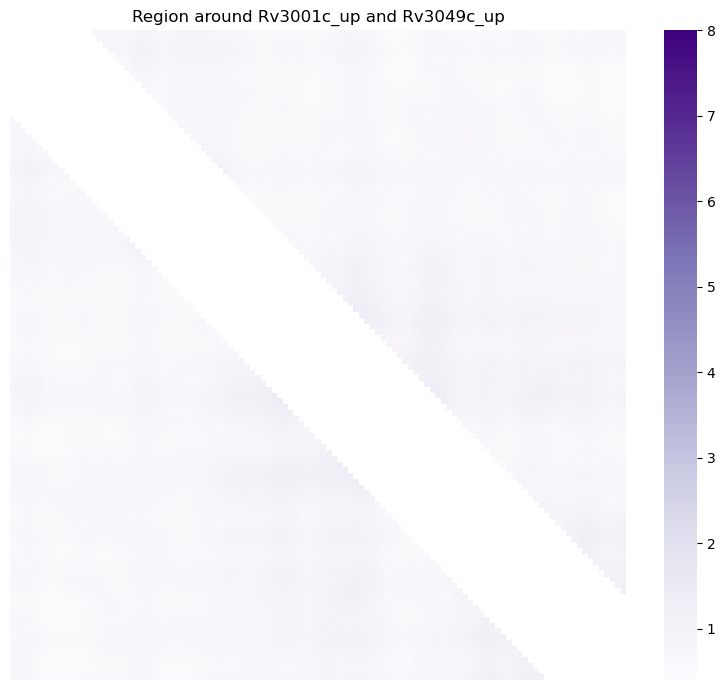

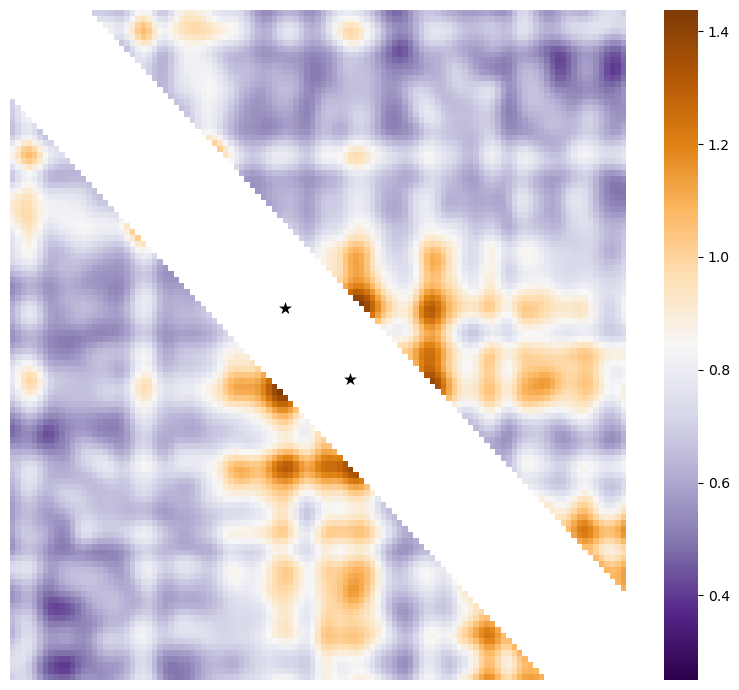

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取 log 转换后的矩阵
df = pd.read_csv("operon_interaction_matrix_OE.csv", index_col=0)

from scipy.ndimage import gaussian_filter

# σ 可自行调整，常用 0.5–2 之间
sigma = 1.75
df = pd.DataFrame(
    gaussian_filter(df.values, sigma=sigma),
    index=df.index,
    columns=df.columns
)

# 设定窗口大小（向上/向下各取 window 个 operon）
window = 50
targets = ["Rv3001c_up", "Rv3049c_up"]

# 计算起止位置
positions = [df.index.get_loc(gene) for gene in targets]
low = max(min(positions) - window, 0)
high = min(max(positions) + window, len(df) - 1)

# 提取子矩阵
sub_df = df.iloc[low:high + 1, low:high + 1]

# 绘制热图
plt.figure(figsize=(8, 7))
sns.heatmap(sub_df, cmap="Purples", vmax=8, xticklabels=False, yticklabels=False)
plt.title(f"Region around {targets[0]} and {targets[1]}")
plt.tight_layout()
plt.show()

# 继续上一步的 sub_df 提取
targets = ["Rv3001c_up", "Rv3049c_up"]
rel_idx = [sub_df.index.get_loc(g) for g in targets if g in sub_df.index]

plt.figure(figsize=(8, 7))
#PuOr_r
ax = sns.heatmap(sub_df, cmap="PuOr_r", xticklabels=False, yticklabels=False,vmin=0.25)

# 在目标行/列处画红色指示线并加星标
for pos, gene in zip(rel_idx, targets):
    # ax.axhline(pos, color="red", lw=1.2)
    # ax.axvline(pos, color="red", lw=1.2)
    ax.text(pos + 0.5, pos + 0.5, "★", ha="center", va="center",
            color="black", fontsize=12, fontweight="bold")

# plt.title("Highlighted Region around Rv3004_up and Rv3046c_up")
plt.tight_layout()
plt.savefig('operon_interaction_sample1.pdf')
plt.show()



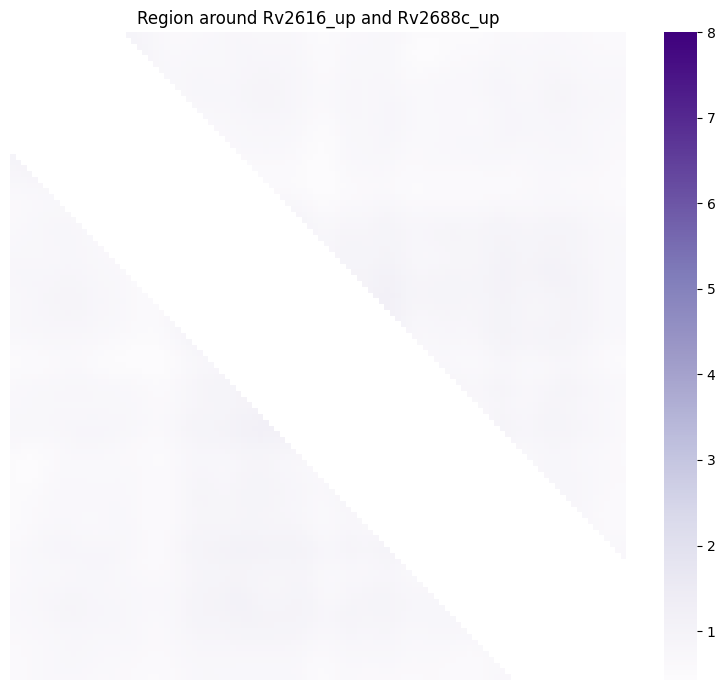

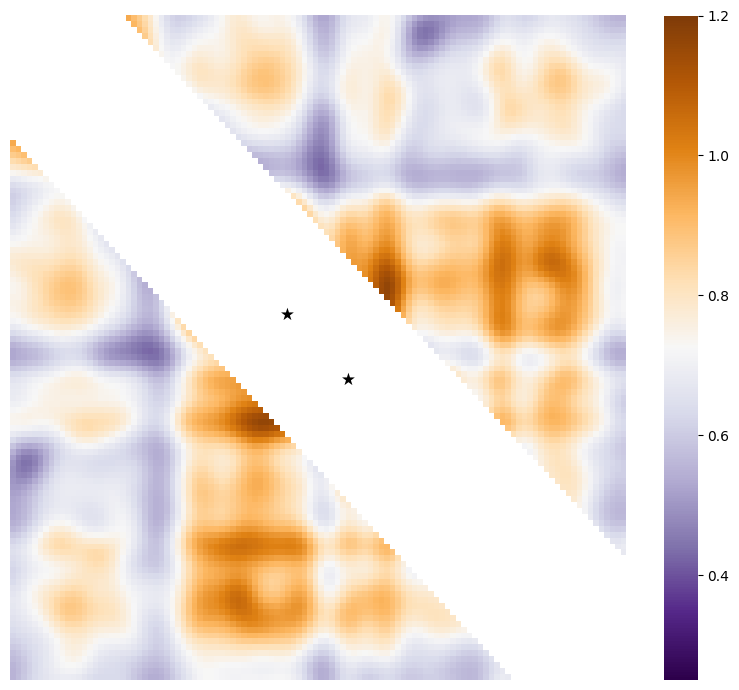

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取 log 转换后的矩阵
df = pd.read_csv("operon_interaction_matrix_OE.csv", index_col=0)

from scipy.ndimage import gaussian_filter

# σ 可自行调整，常用 0.5–2 之间
sigma = 2.5
df = pd.DataFrame(
    gaussian_filter(df.values, sigma=sigma),
    index=df.index,
    columns=df.columns
)

# 设定窗口大小（向上/向下各取 window 个 operon）
window = 50
targets = ["Rv2616_up", "Rv2688c_up"]

# 计算起止位置
positions = [df.index.get_loc(gene) for gene in targets]
low = max(min(positions) - window, 0)
high = min(max(positions) + window, len(df) - 1)

# 提取子矩阵
sub_df = df.iloc[low:high + 1, low:high + 1]

# 绘制热图
plt.figure(figsize=(8, 7))
sns.heatmap(sub_df, cmap="Purples", vmax=8, xticklabels=False, yticklabels=False)
plt.title(f"Region around {targets[0]} and {targets[1]}")
plt.tight_layout()
plt.show()

# 继续上一步的 sub_df 提取
targets = ["Rv2616_up", "Rv2688c_up"]
rel_idx = [sub_df.index.get_loc(g) for g in targets if g in sub_df.index]

plt.figure(figsize=(8, 7))
#PuOr_r
ax = sns.heatmap(sub_df, cmap="PuOr_r", xticklabels=False, yticklabels=False,vmax=1.2,vmin=0.25)

# 在目标行/列处画红色指示线并加星标
for pos, gene in zip(rel_idx, targets):
    # ax.axhline(pos, color="red", lw=1.2)
    # ax.axvline(pos, color="red", lw=1.2)
    ax.text(pos + 0.5, pos + 0.5, "★", ha="center", va="center",
            color="black", fontsize=12, fontweight="bold")

# plt.title("Highlighted Region around Rv3004_up and Rv3046c_up")
plt.tight_layout()
plt.savefig('operon_interaction_sample2.pdf')
plt.show()


In [63]:
sub_df.to_csv('tmp.csv')

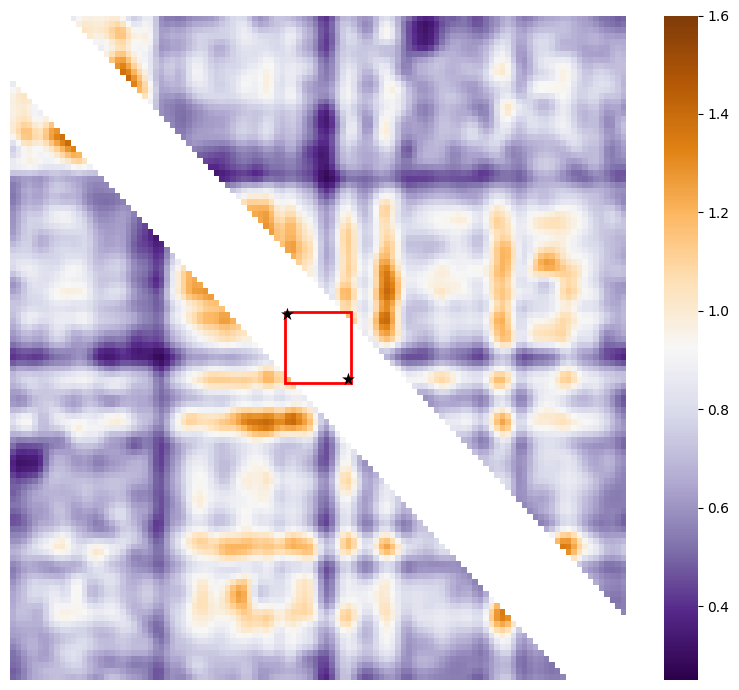

In [51]:
from matplotlib.patches import Rectangle

# 继续上一步的 sub_df 和 rel_idx
box_start = min(rel_idx)
box_end = max(rel_idx)
box_size = box_end - box_start + 1

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    sub_df,
    cmap="PuOr_r",
    xticklabels=False,
    yticklabels=False,
    vmax=1.6,
    vmin=0.25,
)

# 画矩形框标记目标区域
rect = Rectangle(
    (box_start, box_start),
    box_size,
    box_size,
    fill=False,
    edgecolor="red",
    linewidth=2,
)
ax.add_patch(rect)

# 在矩形框中心位置加星标
for pos in rel_idx:
    ax.text(
        pos + 0.5,
        pos + 0.5,
        "★",
        ha="center",
        va="center",
        color="black",
        fontsize=12,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("operon_interaction_sample2.pdf")
plt.show()


In [19]:
import pandas as pd
import numpy as np

# 读取原始互作矩阵（未 log 处理）
df = pd.read_csv("operon_interaction_matrix.csv", index_col=0)
M = df.values
n = M.shape[0]

# 计算不同距离(d = |i-j|)的期望值
dist = np.abs(np.subtract.outer(np.arange(n), np.arange(n)))
exp = np.zeros_like(M, dtype=float)
for d in range(n):
    mask = dist == d
    if d == 0:         # 主对角线稍后置 NaN
        continue
    exp_val = M[mask].mean()
    exp[mask] = exp_val if exp_val != 0 else 1   # 避免除零

# O/E 归一化
oe = M / exp
np.fill_diagonal(oe, np.nan)  # 消除对角线影响

oe_df = pd.DataFrame(oe, index=df.index, columns=df.columns)
oe_df.to_csv("operon_interaction_matrix_OE.csv")
print("O/E 归一化完成，已保存为 operon_interaction_matrix_OE.csv")


/var/folders/fx/kq02x0j96k7djvp1glvrx3vh0000gn/T/ipykernel_6722/2146617833.py:20: RuntimeWarning: divide by zero encountered in divide
  oe = M / exp


O/E 归一化完成，已保存为 operon_interaction_matrix_OE.csv


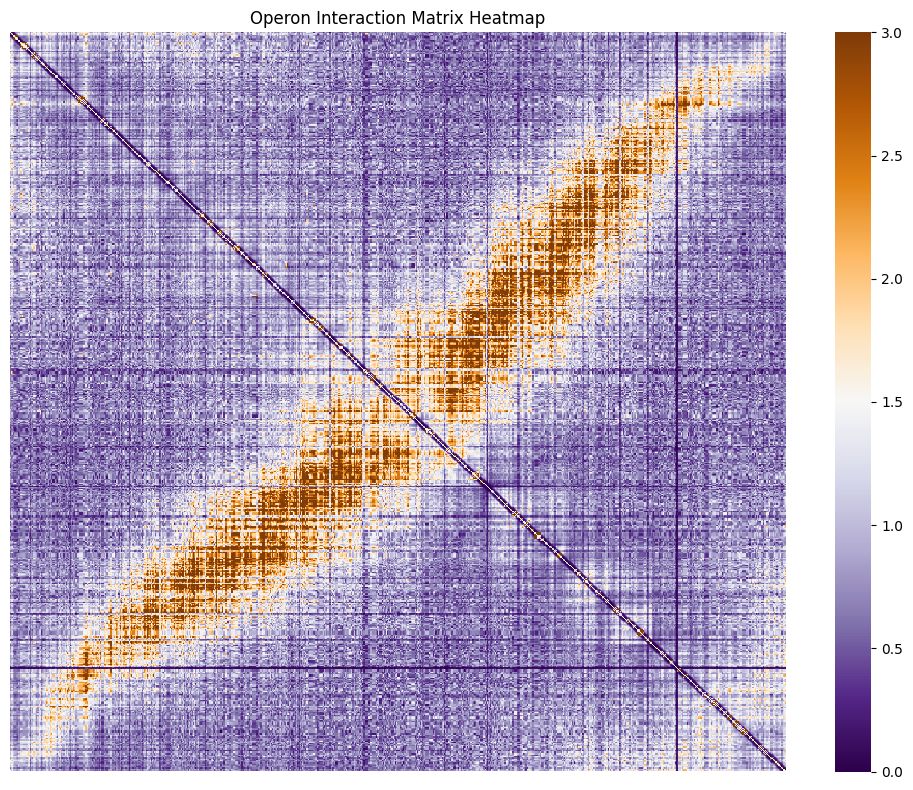

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载 operon 互作矩阵
df = pd.read_csv("operon_interaction_matrix_OE.csv", index_col=0)

plt.figure(figsize=(10, 8))
sns.heatmap(df, cmap="PuOr_r", xticklabels=False, yticklabels=False,
            vmax=3)
plt.title("Operon Interaction Matrix Heatmap")
plt.tight_layout()
plt.savefig('operon_matrix.png', dpi=300)
plt.show()

Operon 互作矩阵已进行 log 转换并保存为 operon_interaction_matrix.csv


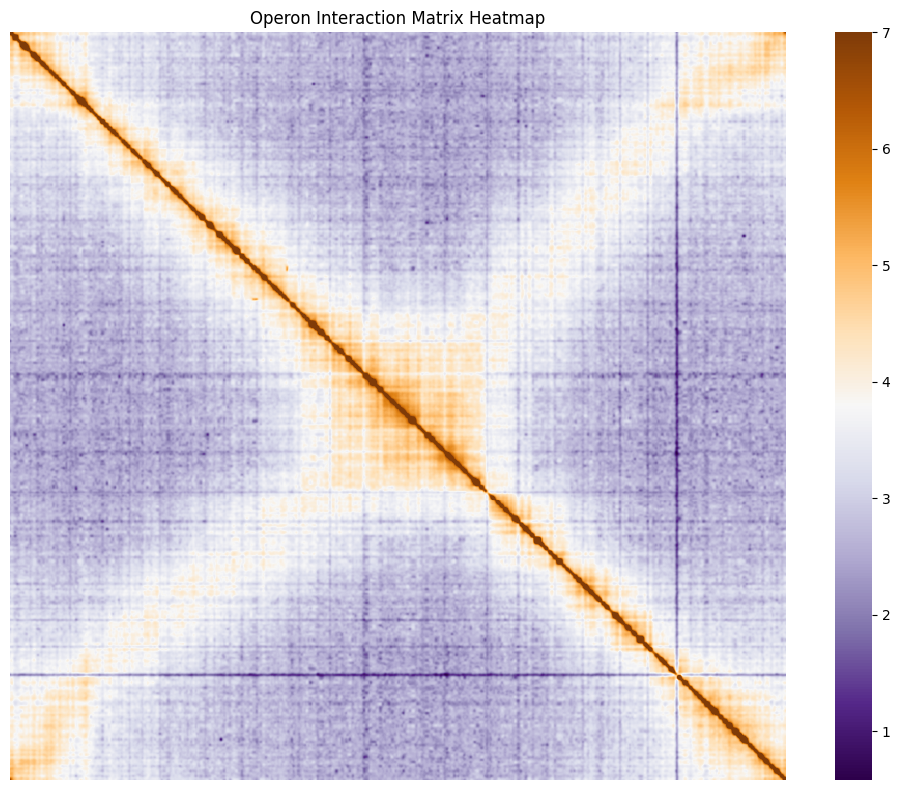

In [88]:
import pandas as pd
import numpy as np

# 读取 operon 互作矩阵
df = pd.read_csv("operon_interaction_matrix.csv", index_col=0)

# 为避免 log(0) 的问题，这里使用 log1p (即 log(x+1) 转换)
df_log = np.log1p(df)

# 保存转换后的矩阵，覆盖原文件或另存为新文件
df_log.to_csv("operon_interaction_matrix_log.csv")
print("Operon 互作矩阵已进行 log 转换并保存为 operon_interaction_matrix.csv")


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载 operon 互作矩阵
df = pd.read_csv("operon_interaction_matrix_log.csv", index_col=0)
sigma = 1
df = pd.DataFrame(
    gaussian_filter(df.values, sigma=sigma),
    index=df.index,
    columns=df.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(df, cmap="PuOr_r", xticklabels=False, yticklabels=False,
            vmax=7)
plt.title("Operon Interaction Matrix Heatmap")
plt.tight_layout()
plt.savefig('operon_matrix.png', dpi=300)
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


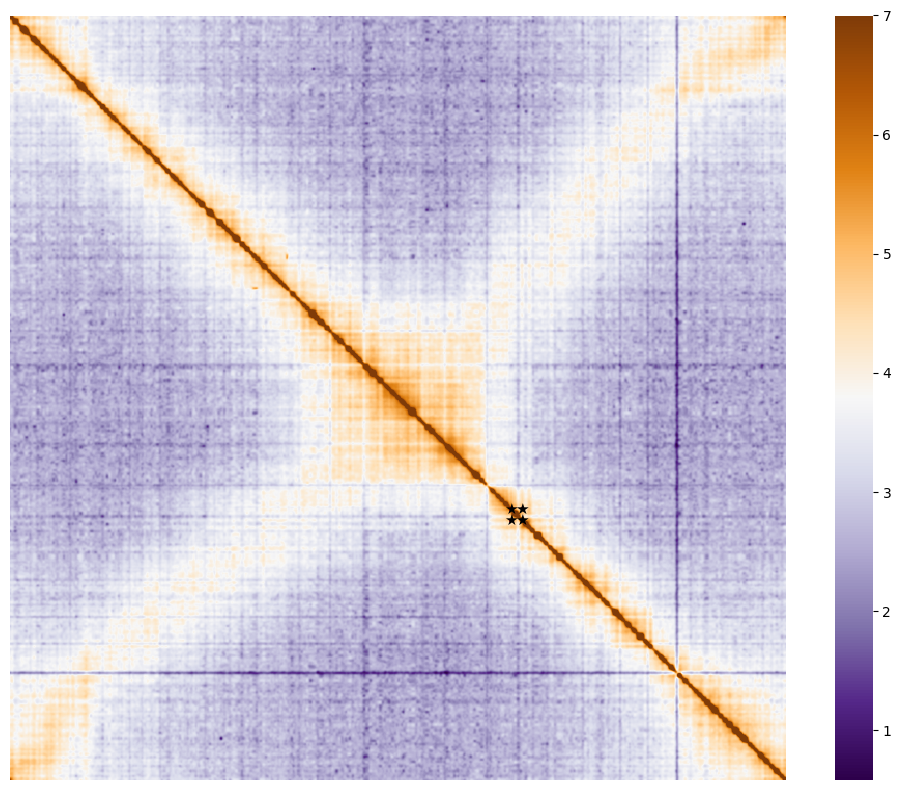

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Rectangle

# 读取并平滑
df = pd.read_csv("operon_interaction_matrix_log.csv", index_col=0)
df = pd.DataFrame(gaussian_filter(df.values, sigma=1), index=df.index, columns=df.columns)

# 目标 operon
targets = ["Rv2616_up", "Rv2688c_up"]
idx = [df.index.get_loc(g) for g in targets]   # 目标在矩阵中的索引

# 绘图
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df, cmap="PuOr_r", vmax=7, xticklabels=False, yticklabels=False)

# 把目标像素块（对角 + 互作）框出并加星标
for r in idx:
    for c in idx:                             # (r,c) 覆盖对角及互作两块
        ax.add_patch(Rectangle((c, r), 1, 1, fill=False, edgecolor="red", lw=1.4))
        ax.text(c + 0.5, r + 0.5, "★", ha="center", va="center",
                color="black", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("operon_matrix_targets.png", dpi=300)
plt.show()


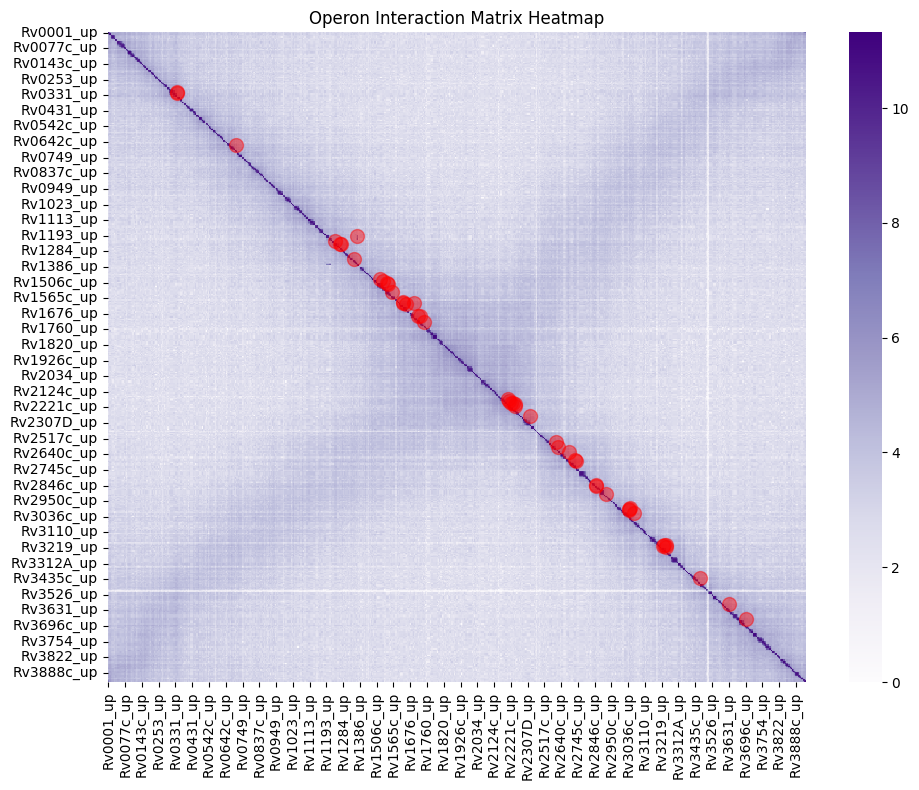

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 加载转化后的 operon 互作矩阵数据
df = pd.read_csv("operon_interaction_matrix_log.csv", index_col=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(df, cmap="Purples")
plt.title("Operon Interaction Matrix Heatmap")

# 加载 filtered_operon_pairs 数据
df_pairs = pd.read_csv("filtered_operon_pairs.csv")
operons = list(df.index)

# 遍历每一对 operon，不区分前后顺序，只标记一次
for _, row in df_pairs.iterrows():
    op1, op2 = row["operon1"], row["operon2"]
    if op1 in operons and op2 in operons:
        idx1, idx2 = operons.index(op1), operons.index(op2)
        i, j = min(idx1, idx2), max(idx1, idx2)
        plt.scatter(j + 0.5, i + 0.5, s=100, color="red", alpha=0.45)

plt.tight_layout()
plt.show()


In [24]:
import pandas as pd
import numpy as np

# 加载 operon 互作矩阵
df = pd.read_csv("operon_interaction_matrix.csv", index_col=0)
A = df.values

def kr_normalization(A, tol=1e-5, max_iter=1000):
    """
    使用迭代校正的方法实现类似 Knight-Ruiz (KR) 的矩阵平衡
    目的是求出对角因子 d，使得 diag(d) * A * diag(d) 的行和相近相等
    此处算法类似于 ICE 矫正，适用于对称矩阵
    """
    n = A.shape[0]
    d = np.ones(n)
    
    for _ in range(max_iter):
        row_sum = A.dot(d)
        new_d = d.copy()
        # 仅对非零行进行更新，防止除零错误
        nonzero = row_sum > 0
        new_d[nonzero] = d[nonzero] / row_sum[nonzero]
        if np.max(np.abs(new_d - d)) < tol:
            d = new_d
            break
        d = new_d
        
    # 得到 KR 矫正后的矩阵
    norm_A = np.outer(d, d) * A
    return norm_A, d

norm_A, d = kr_normalization(A)

# 将 KR 矫正后的矩阵保存为 CSV 文件
df_norm = pd.DataFrame(norm_A, index=df.index, columns=df.columns)
df_norm.to_csv("operon_interaction_matrix_KR.csv")
print("KR矫正后的矩阵已保存为 operon_interaction_matrix_KR.csv")


KR矫正后的矩阵已保存为 operon_interaction_matrix_KR.csv


In [ ]:
import numpy as np
import pandas as pd
import glob
import os

# 定义 Shannon 熵函数
def shannon_entropy(data):
    # 将数据离散化（如果数据连续，可根据需要调整离散化方式，这里直接使用 unique 值）
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    # 熵值计算，底数为2
    return -np.sum(probs * np.log2(probs))

# 定义 1D Moran's I 指数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    
    # 构造权重矩阵，只考虑相邻元素
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    # 计算分子部分
    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    
    denominator = np.sum((data - mean_data)**2)
    
    return (n * numerator) / (denominator * np.sum(w))

data_dir = './DI-score/'
# 使用 glob 获取目录下所有 CSV 文件
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

# 存储结果的 DataFrame
results = []

for file in csv_files:
    print(file)
    df = pd.read_csv(file, header=None)
    data = df.values.flatten()
    se = shannon_entropy(data)
    gini = gini_coefficient(data)
    moran = morans_i_1d(data)
    results.append({
        'file': os.path.basename(file),
        'shannon_entropy': se,
        'gini_coefficient': gini,
        "morans_i_1d": moran
    })

# 用 DataFrame 展示结果
results_df = pd.DataFrame(results)
print(results_df)


./DI-score/DI-100kb_latent.csv
./DI-score/DI-100kb_wt.csv
./DI-score/DI-100kb_napm.csv
./DI-score/DI-napm-ko-hypoxia.csv
./DI-score/DI-100kb_hypoxia.csv
                     file  shannon_entropy  gini_coefficient  morans_i_1d
0     DI-100kb_latent.csv          9.78627        -59.788142     0.725521
1         DI-100kb_wt.csv          9.78627         52.736411     0.942718
2       DI-100kb_napm.csv          9.78627        -18.004204     0.944236
3  DI-napm-ko-hypoxia.csv          9.78627        -31.488015     0.887139
4    DI-100kb_hypoxia.csv          9.78627         25.994065     0.922381


In [13]:
import numpy as np
import pandas as pd
import glob
import os

# 定义 Shannon 熵函数
def shannon_entropy(data):
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

# 定义 1D Moran's I 指数函数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    denominator = np.sum((data - mean_data) ** 2)
    
    return (n * numerator) / (denominator * np.sum(w))

# 指定 CSV 文件所在目录
data_dir = './DI-score/'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

results = []

for file in csv_files:
    try:
        df = pd.read_csv(file, header=None)
        # 判断数据为行向量或列向量
        if df.shape[0] == 1:
            data = df.values.flatten()
        elif df.shape[1] == 1:
            data = df.values.flatten()
        else:
            data = df.iloc[0, :].values
        
        # 对数据进行截断处理：大于2的值变为2，小于-2的值变为-2
        data = np.clip(data, -2, 2)
        
        se = shannon_entropy(data)
        gini = gini_coefficient(data)
        moran = morans_i_1d(data)
        
        results.append({
            'file': os.path.basename(file),
            'shannon_entropy': se,
            "morans_i_1d": moran
        })
    except Exception as e:
        print(f"读取或处理文件 {file} 时出错：{e}")

results_df = pd.DataFrame(results)
print(results_df)


                     file  shannon_entropy  morans_i_1d
0     DI-100kb_latent.csv         8.974048     0.760497
1         DI-100kb_wt.csv         3.007730     0.947671
2    DI-napm-ko-100kb.csv         3.676685     0.942586
3  DI-napm-ko-hypoxia.csv         5.083292     0.863184
4    DI-100kb_hypoxia.csv         3.485555     0.927735


                  file  shannon_entropy  morans_i_1d
0               wt.csv         3.007730     0.947671
1          napm-ko.csv         3.676685     0.942586
2  napm-ko-hypoxia.csv         5.083292     0.863184
3          hypoxia.csv         3.485555     0.927735
4           latent.csv         8.974048     0.760497


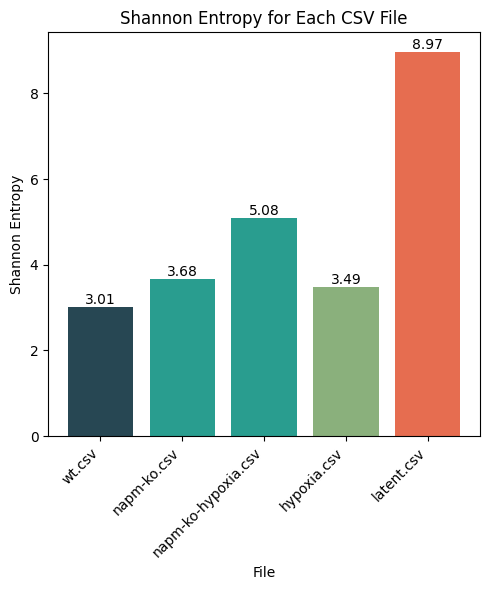

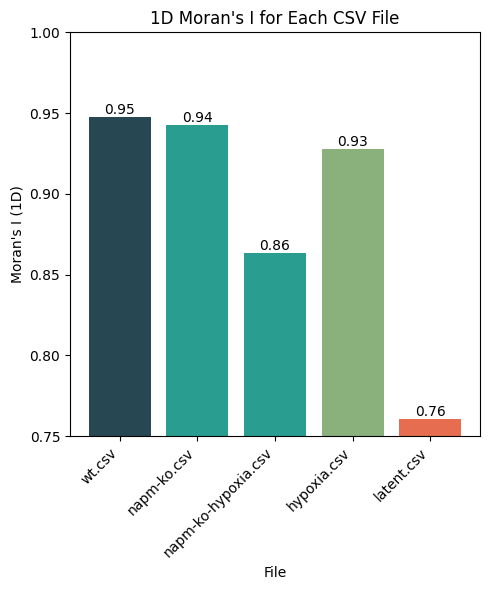

In [28]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 定义颜色映射字典
color_map = {
    'wt': '#274753',
    'napm-ko': '#299d8f',
    'hypoxia': '#8ab07c',
    'napm-ko-hypoxia': '#f3a361',
    'latent': '#e66d50'
}

# 定义获取文件对应颜色的函数
def get_color(filename, color_map):
    for key, color in color_map.items():
        if key in filename:
            return color
    return '#333333'  # 如果找不到，返回默认颜色

# 定义 Shannon 熵函数
def shannon_entropy(data):
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))


# 定义 1D Moran's I 指数函数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    denominator = np.sum((data - mean_data) ** 2)
    return (n * numerator) / (denominator * np.sum(w))

data_dir = './DI-score/'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

results = []

for file in csv_files:
    try:
        df = pd.read_csv(file, header=None)
        if df.shape[0] == 1:
            data = df.values.flatten()
        elif df.shape[1] == 1:
            data = df.values.flatten()
        else:
            data = df.iloc[0, :].values
        
        data = np.clip(data, -2, 2)
        
        se = shannon_entropy(data)
        gini = gini_coefficient(data)
        moran = morans_i_1d(data)
        
        results.append({
            'file': os.path.basename(file),
            'shannon_entropy': se,
        #     'gini_coefficient': gini,
            "morans_i_1d": moran
        })
    except Exception as e:
        print(f"读取或处理文件 {file} 时出错：{e}")

results_df = pd.DataFrame(results)
print(results_df)

# 根据文件名获取每个文件对应的颜色
bar_colors = [get_color(fname, color_map) for fname in results_df['file']]

# 绘制 Shannon 熵柱状图，并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df['shannon_entropy'], color=bar_colors)
plt.xlabel('File')
plt.ylabel('Shannon Entropy')
plt.title('Shannon Entropy for Each CSV File')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# 绘制 1D Moran's I 指数柱状图，并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df["morans_i_1d"], color=bar_colors)
plt.xlabel('File')
plt.ylabel("Moran's I (1D)")
plt.title("1D Moran's I for Each CSV File")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.75,1)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


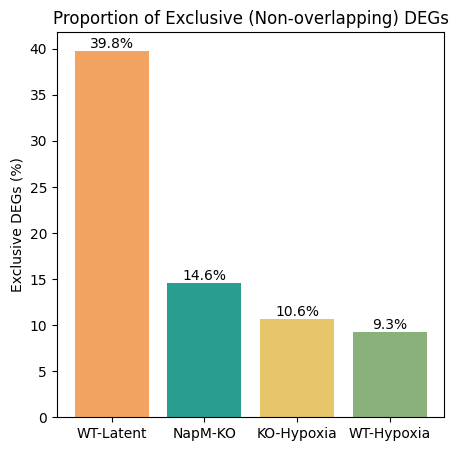

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

exclusive_counts = {
    "WT-Hypoxia": 140,
    "NapM-KO": 76,
    "KO-Hypoxia": 174,
    "WT-Latent": 765
}

totals = {
    "WT-Hypoxia": 140 + 42 + 44 + 385 + 96 + 614 + 138 + 48,
    "NapM-KO": 76 + 42 + 44 + 91 + 96 + 83 + 58 + 31,
    "KO-Hypoxia": 385 + 44 + 96 + 614 + 147 + 174 + 91 + 83,
    "WT-Latent": 765 + 147 + 83 + 31 + 48 + 96 + 614 + 138
}

ratios = {g: exclusive_counts[g]/totals[g] for g in exclusive_counts}

df = pd.DataFrame({
    "Group": list(ratios.keys()),
    "Exclusive": list(exclusive_counts.values()),
    "Total": [totals[g] for g in ratios.keys()],
    "Exclusive_ratio": list(ratios.values())
}).sort_values("Exclusive_ratio", ascending=False).reset_index(drop=True)

# 为每组指定颜色
colors = {
    "WT-Hypoxia": "#8ab07c",
    "NapM-KO": "#299d8f", 
    "KO-Hypoxia": "#e7c66b",  
    "WT-Latent": "#f3a361"
}
bar_colors = [colors[g] for g in df["Group"]]

plt.figure(figsize=(5,5))
plt.bar(df["Group"], df["Exclusive_ratio"]*100, color=bar_colors)
for i,v in enumerate(df["Exclusive_ratio"]*100):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.ylabel("Exclusive DEGs (%)")
plt.title("Proportion of Exclusive (Non-overlapping) DEGs")
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Jaccard(WT-Hypoxia, WT-Latent) = 0.3537


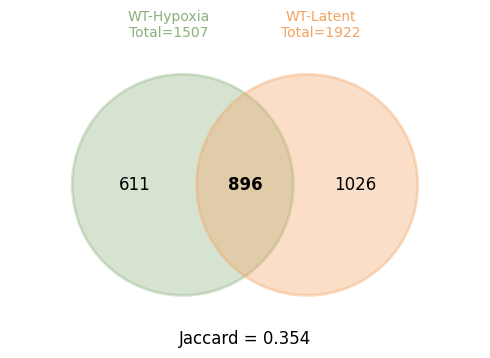

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 输入：两组总数与交集
A_name, B_name = "WT-Hypoxia", "WT-Latent"
A_total = 140 + 42 + 44 + 385 + 96 + 614 + 138 + 48   # 1507
B_total = 765 + 147 + 83 + 31 + 48 + 96 + 614 + 138   # 1922
intersect = 614 + 138 + 48 + 96                       # 896

# 计算独有、并集、Jaccard
A_only = A_total - intersect
B_only = B_total - intersect
union = A_total + B_total - intersect
jaccard = intersect / union if union > 0 else 0.0
print(f"Jaccard({A_name}, {B_name}) = {jaccard:.4f}")

# 配色
colors = {
    "WT-Hypoxia": "#8ab07c",
    "WT-Latent": "#f3a361"
}

# 画维恩图
fig, ax = plt.subplots(figsize=(5,4))
r = 1.6
cA = (0, 0)
cB = (1.8, 0)

circleA = Circle(cA, r, edgecolor=colors[A_name], facecolor=colors[A_name], alpha=0.35, lw=2)
circleB = Circle(cB, r, edgecolor=colors[B_name], facecolor=colors[B_name], alpha=0.35, lw=2)
ax.add_patch(circleA)
ax.add_patch(circleB)

# 标注计数
ax.text(cA[0]-0.7, 0, str(A_only), ha="center", va="center", fontsize=12)
ax.text((cA[0]+cB[0])/2, 0, str(intersect), ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(cB[0]+0.7, 0, str(B_only), ha="center", va="center", fontsize=12)

# 标注组名与总数
ax.text(cA[0]-0.2, r+0.5, f"{A_name}\nTotal={A_total}", ha="center", va="bottom", color=colors[A_name])
ax.text(cB[0]+0.2, r+0.5, f"{B_name}\nTotal={B_total}", ha="center", va="bottom", color=colors[B_name])

# 标注Jaccard
ax.text((cA[0]+cB[0])/2, -r-0.5, f"Jaccard = {jaccard:.3f}", ha="center", va="top", fontsize=12)

ax.set_xlim(-2.5, 4.3)
ax.set_ylim(-2.3, 2.3)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("venn_diagram.pdf", dpi=300)
plt.show()


                  file  shannon_entropy  gini_coefficient  morans_i_1d
0               wt.csv         3.007730         20.989120     0.947671
1          napm-ko.csv         3.676685        -28.117352     0.942586
2          hypoxia.csv         3.485555          7.390472     0.927735
3  napm-ko-hypoxia.csv         5.083292       6183.791343     0.863184
4           latent.csv         8.974048        -26.702423     0.760497


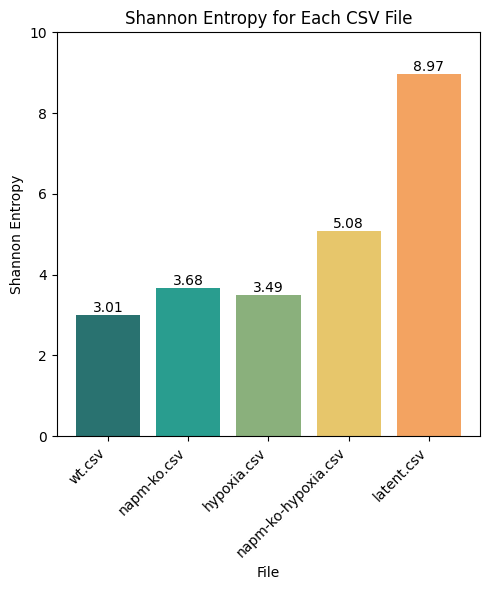

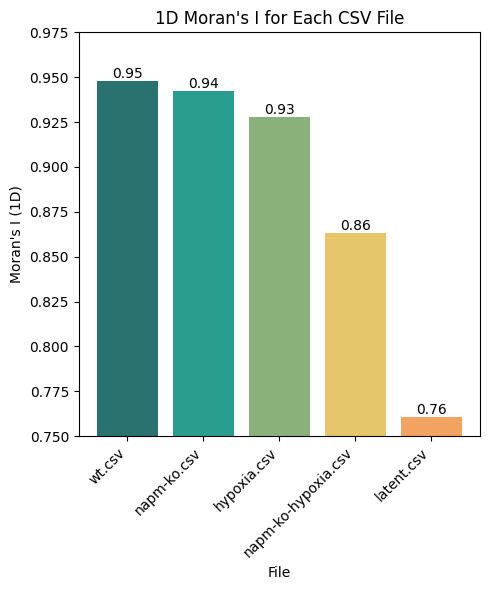

In [35]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 按照指定顺序和对应颜色
files_order = ['wt.csv', 'napm-ko.csv', 'hypoxia.csv', 'napm-ko-hypoxia.csv', 'latent.csv']
colors = ['#297270', '#299d8f', '#8ab07c', '#e7c66b', '#f3a361']

# 定义 Shannon 熵函数
def shannon_entropy(data):
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

# 定义 Gini 系数函数
def gini_coefficient(data):
    n = len(data)
    mu = np.mean(data)
    diff_matrix = np.abs(np.subtract.outer(data, data))
    sum_diff = np.sum(diff_matrix)
    return sum_diff / (2 * n**2 * mu)

# 定义 1D Moran's I 指数函数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    denominator = np.sum((data - mean_data) ** 2)
    
    return (n * numerator) / (denominator * np.sum(w))

# CSV 文件所在目录
data_dir = './DI-score/'

results = []
for file_name in files_order:
    file_path = os.path.join(data_dir, file_name)
    try:
        df = pd.read_csv(file_path, header=None)
        # 判断数据为行向量或列向量
        if df.shape[0] == 1:
            data = df.values.flatten()
        elif df.shape[1] == 1:
            data = df.values.flatten()
        else:
            data = df.iloc[0, :].values
        
        # 截断数据：大于 2 的值变为 2，小于 -2 的值变为 -2
        data = np.clip(data, -2, 2)
        
        se = shannon_entropy(data)
        gini = gini_coefficient(data)
        moran = morans_i_1d(data)
        
        results.append({
            'file': file_name,
            'shannon_entropy': se,
            'gini_coefficient': gini,
            'morans_i_1d': moran
        })
    except Exception as e:
        print(f"处理文件 {file_name} 时出错：{e}")

results_df = pd.DataFrame(results)
print(results_df)

# 绘制 Shannon 熵柱状图，使用指定颜色并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df['shannon_entropy'], color=colors)
plt.xlabel('File')
plt.ylabel('Shannon Entropy')
plt.title('Shannon Entropy for Each CSV File')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 10)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('DI-score/shannon_entropy.pdf')
plt.show()

# 绘制 1D Moran's I 指数柱状图，使用指定颜色并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df["morans_i_1d"], color=colors)
plt.xlabel('File')
plt.ylabel("Moran's I (1D)")
plt.title("1D Moran's I for Each CSV File")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.75,0.975)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('DI-score/moran.pdf')
plt.show()


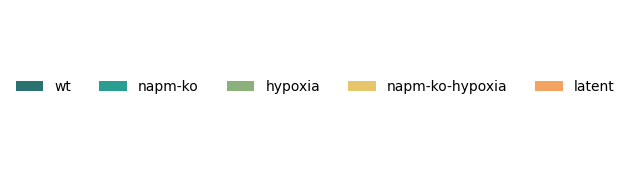

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 定义颜色和对应的标签
labels = ['wt', 'napm-ko', 'hypoxia', 'napm-ko-hypoxia', 'latent']
colors = ['#297270', '#299d8f', '#8ab07c', '#e7c66b', '#f3a361']

# 创建图例条目
legend_elements = [Patch(facecolor=color, label=label) for label, color in zip(labels, colors)]

# 绘制仅显示图例的图
plt.figure(figsize=(6, 2))
plt.legend(handles=legend_elements, loc='center', ncol=len(labels), frameon=False)
plt.axis('off')  # 不显示坐标轴
plt.savefig('DI-score/legend.pdf')
plt.show()


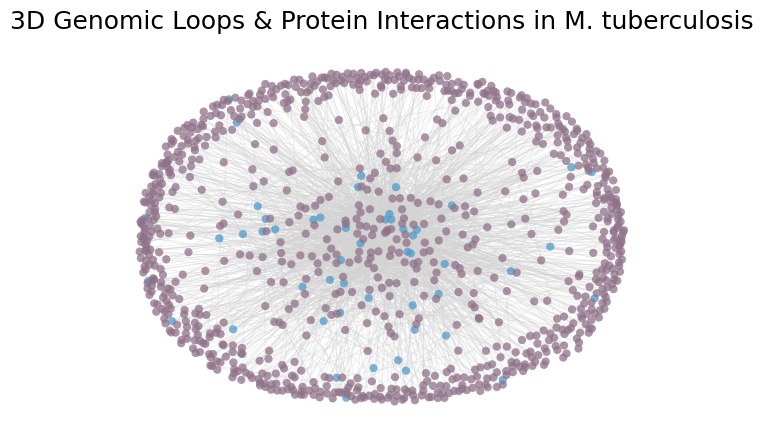

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# 1. 读取数据并构图 -------------------------------------------------------------
edges_df = pd.read_csv('./operon_network/operon_edges.csv')
nodes_df = pd.read_csv('./operon_network/operon_node.csv')

G = nx.Graph()
G.add_nodes_from(
    (row.id, {'type': row.type}) for _, row in nodes_df.iterrows()
)
G.add_edges_from(
    (row.source, row.target, {'interaction_type': row.interaction_type})
    for _, row in edges_df.iterrows()
)

# 2. 预设配色 & 待高亮信息 -------------------------------------------------------
sns.set_context('talk')                 # seaborn 全局样式
dna_color       = '#529ac9'             # DNA 节点
protein_color   = '#8f7289'             # Protein 节点
direct_color    = '#29a15c'             # Direct loop 边
indirect_color  = '#ed7b61'             # Indirect loop 边
other_color     = 'lightgray'           # 其它边
unloop_color    = 'gray'                # Unmediated loop 边

dna_list = []

# 3. 布局 -----------------------------------------------------------------------
pos = nx.spring_layout(G, k=0.5, seed=42, iterations=50)

# 4. 绘制节点 -------------------------------------------------------------------
node_colors = [
    dna_color     if G.nodes[n]['type']=='operon'     else
    protein_color if G.nodes[n]['type']=='protein' else
    'gray'
    for n in G.nodes
]
nx.draw_networkx_nodes(G, pos,
    node_size=35, node_color=node_colors, alpha=0.75, linewidths=0)

# 高亮 dna_list
highlight = [n for n in G if n in dna_list]
nx.draw_networkx_nodes(G, pos,
    nodelist=highlight, node_size=70,
    node_color='none', edgecolors='black', linewidths=1.5
)

# 5. 绘制普通边 (非 DNA-DNA) ----------------------------------------------------
other_edges = [(u,v) for u,v,d in G.edges(data=True)
               if d.get('interaction_type')!='DNA-DNA']
nx.draw_networkx_edges(G, pos, edgelist=other_edges,
    edge_color=other_color, width=0.5, alpha=0.5)

# 6. 封装弯曲边绘制函数 ----------------------------------------------------------
def draw_curved(edges, color, width=1.5, rad=0.25):
    for u,v in edges:
        x1,y1 = pos[u];  x2,y2 = pos[v]
        curve = FancyArrowPatch((x1,y1), (x2,y2),
            connectionstyle=f'arc3,rad={rad}',
            arrowstyle='-', color=color, linewidth=width, alpha=0.85)
        plt.gca().add_patch(curve)


# 8. 图例 -----------------------------------------------------------------------
legend = [
    Line2D([0],[0],color=direct_color,   lw=2, label='Directly mediated loops'),
    Line2D([0],[0],color=indirect_color, lw=2, label='Indirectly mediated loops'),
    Line2D([0],[0],color=unloop_color,   lw=2, label='Non-loop interactions'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=dna_color,
           markersize=10,label='DNA'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=protein_color,
           markersize=10,label='Protein'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=dna_color,
           markeredgecolor='black',markeredgewidth=1.5,
           markersize=10,label='CID boundary')
]
# plt.legend(handles=legend, loc='best')
plt.title('3D Genomic Loops & Protein Interactions in M. tuberculosis')
plt.axis('off')
plt.tight_layout()
plt.show()

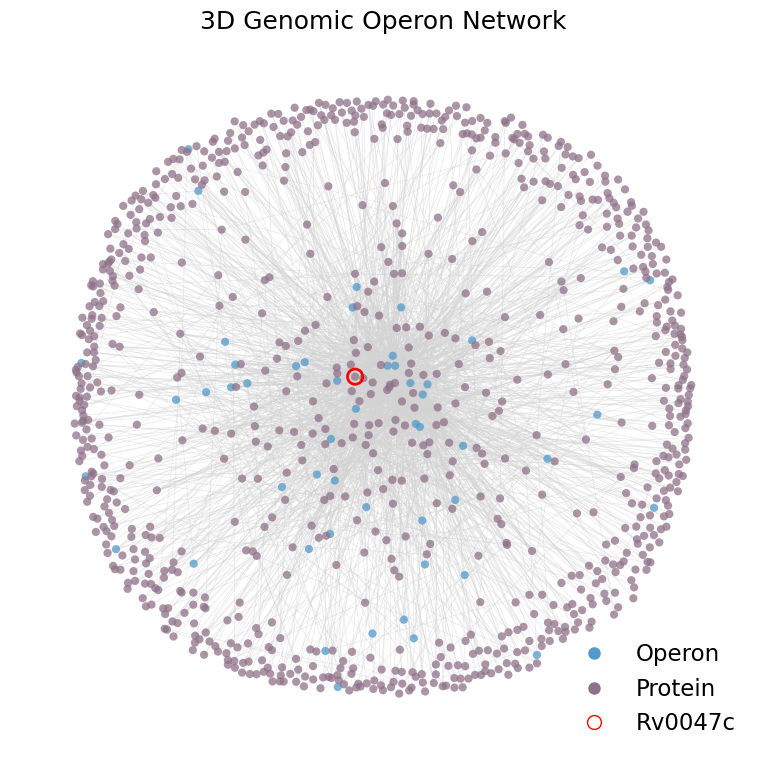

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# 读取数据 ---------------------------------------------------------------------
edges_df = pd.read_csv('./operon_network/operon_edges.csv')
nodes_df = pd.read_csv('./operon_network/operon_node.csv')

G = nx.Graph()
G.add_nodes_from((row.id, {'type': row.type}) for _, row in nodes_df.iterrows())
G.add_edges_from(
    (row.source, row.target, {'interaction_type': row.interaction_type})
    for _, row in edges_df.iterrows()
)

# 全局样式 & 配色 --------------------------------------------------------------
sns.set_context('talk')
dna_color, protein_color = '#529ac9', '#8f7289'
other_color = 'lightgray'

# 布局 -------------------------------------------------------------------------
pos = nx.spring_layout(G, k=0.5, seed=42, iterations=50)

# 绘图 -------------------------------------------------------------------------
plt.figure(figsize=(8, 8))

node_colors = [
    dna_color if G.nodes[n]['type'] == 'operon'
    else protein_color if G.nodes[n]['type'] == 'protein'
    else 'gray'
    for n in G.nodes
]
nx.draw_networkx_nodes(G, pos, node_size=35, node_color=node_colors,
                       alpha=0.75, linewidths=0)

# Rv0047c 高亮 & 标注 ----------------------------------------------------------
rv0047c_nodes = [n for n in G.nodes if 'Rv0047c' in n]
nx.draw_networkx_nodes(G, pos, nodelist=rv0047c_nodes, node_size=120,
                       node_color='none', edgecolors='red', linewidths=2)

    # plt.text(x, y + 0.02, n, fontsize=12, fontweight='bold',
    #          color='red', ha='center', va='center')

# 非 DNA-DNA 边 ---------------------------------------------------------------
other_edges = [(u, v) for u, v, d in G.edges(data=True)
               if d.get('interaction_type') != 'DNA-DNA']
nx.draw_networkx_edges(G, pos, edgelist=other_edges, edge_color=other_color,
                       width=0.5, alpha=0.5)

# 图例 -------------------------------------------------------------------------
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=dna_color,
           markersize=10, label='Operon'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=protein_color,
           markersize=10, label='Protein'),
    Line2D([0], [0], marker='o', color='w', markeredgecolor='red',
           markerfacecolor='none', markeredgewidth=1, markersize=10,
           label='Rv0047c')
]
plt.legend(handles=legend, frameon=False, loc='best')
plt.title('3D Genomic Operon Network')
plt.axis('off')
plt.tight_layout()
plt.savefig('operon_network.pdf')
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["cid", "loop", "operon", "protein"]
counts = np.array([21, 10, 7, 14])
averages = np.array([3.65, 1.31, 2.88, 2.02])

# Style (Nature-like)
plt.rcParams.update({
    "font.size": 9,
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi": 200,
})

# Combined Figure
fig, ax1 = plt.subplots(figsize=(3.35, 2.3))  # ~85 mm width

x = np.arange(len(categories))
bar_width = 0.6

# Bar plot for counts (left y-axis)
bars = ax1.bar(x, counts, width=bar_width, color="#4a90a4", label="Count")

# Add value labels
for rect, val in zip(bars, counts):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height(), f"{val}",
             ha='center', va='bottom', fontsize=8)

ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Second axis for averages
ax2 = ax1.twinx()
ax2.plot(x, averages, marker='o', color="#e38933", linestyle='-', linewidth=1, label="Average")

for xi, yi in zip(x, averages):
    ax2.text(xi, yi, f"{yi:.2f}", ha='center', va='bottom', fontsize=8, color="#e38933")

ax2.set_ylabel("Average")

# Unify legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig("Nature_style_combined.png", bbox_inches="tight", facecolor="white")
fig.savefig("Nature_style_combined.svg", bbox_inches="tight", facecolor="white")
plt.close(fig)

# "/mnt/data/Nature_style_combined.png", "/mnt/data/Nature_style_combined.svg"


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
